#Oasis infobyte internship - Task 1
## Exploratory Data Analysis on Retail Sales Data

## Objective
The objective of this project is to perform exploratory data analysis on retial
Sales data to identify sales trends , customer charecteristics , product
Performance , category-wise revenue patterns, and other actionable business insights .

### Tools & technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Retail_Sales.csv to Retail_Sales.csv


In [ ]:
import pandas as pd
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [ ]:
df.shape

(2000, 11)

In [ ]:
df.columns

Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [ ]:
df.isnull().sum()

,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,10
category,0
quantiy,3
price_per_unit,3
cogs,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(10)

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0
5,1559,2022-08-20,07:40:00,49,Female,40.0,Clothing,4.0,300.0,144.0,1200.0
6,163,2022-10-31,09:38:00,144,Female,64.0,Clothing,3.0,50.0,23.0,150.0
7,303,2022-04-22,11:09:00,54,Male,19.0,Electronics,3.0,30.0,14.7,90.0
8,421,2022-04-08,08:43:00,66,Female,37.0,Clothing,3.0,500.0,235.0,1500.0
9,979,2022-05-18,10:18:00,6,Female,19.0,Beauty,1.0,25.0,10.5,25.0


In [ ]:
df.describe()

,transactions_id,customer_id,age,quantiy,price_per_unit,cogs,total_sale
count,2000.000000,2000.000000,1990.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.500000,66.341500,41.343216,2.512769,180.117677,95.023886,456.544817
std,577.494589,44.937185,13.668167,1.132708,189.685225,121.898695,560.101381
min,1.000000,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.750000,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1000.500000,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1500.250000,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000


In [ ]:
df[df.isnull().any(axis=1)]

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
24,432,2022-03-10,11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0
25,1367,2022-04-15,11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0
26,1391,2022-03-01,11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0
27,1432,2022-12-25,06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0
28,150,2022-04-13,08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0
29,845,2022-10-27,10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0
30,1150,2022-08-22,10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0
31,1845,2022-05-24,07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0
32,797,2022-09-16,06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0
33,921,2022-09-28,09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0


In [ ]:
print(df.columns.tolist())

['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']


In [ ]:
#clean the column names
df.columns = df.columns.str.strip()

#Correct the column name
df = df.rename(columns={"quantiy":"quantity"})

#Remove rows with missing essentials sales information
df = df.dropna(subset=["quantity","price_per_unit", "cogs","total_sale"])

#Fill missing age with median age
df["age"] = df["age"].fillna(df['age'].median())

#check missing values
df.isnull().sum()


,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price_per_unit,0
cogs,0


In [ ]:
df["sale_date"] = pd.to_datetime(df['sale_date'])

In [ ]:
df["sale_date"].dtype

dtype('<M8[ns]')

In [ ]:
df["month"]= df["sale_date"].dt.month

In [ ]:
df["quarter"] = df["sale_date"].dt.quarter

In [ ]:
monthly_sales = df.groupby("month")["total_sale"].sum()

In [ ]:
monthly_sales

,total_sale
month,
1,46425.0
2,41280.0
3,45035.0
4,50630.0
5,51990.0
6,45255.0
7,58120.0
8,49465.0
9,129330.0


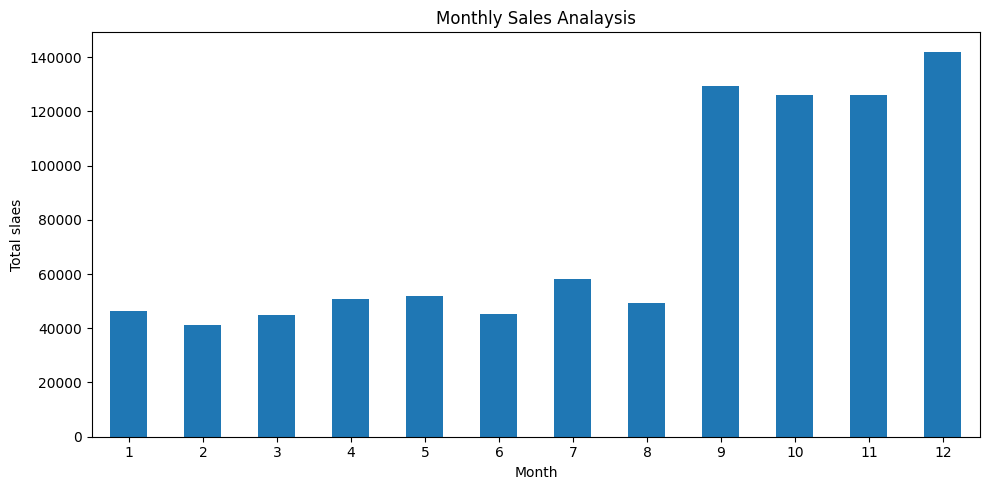

In [ ]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Analaysis")
plt.xlabel("Month")
plt.ylabel("Total slaes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

quarter
1    132740.0
2    147875.0
3    236915.0
4    394190.0
Name: total_sale, dtype: float64


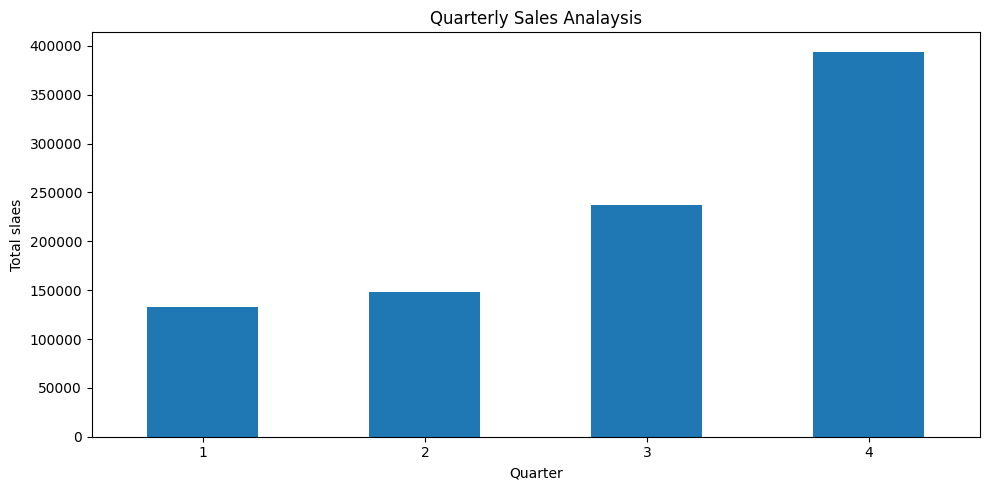

In [ ]:
# Quarterly Sales Trend
import matplotlib.pyplot as plt
quarterly_sales = df.groupby("quarter")["total_sale"].sum()

print(quarterly_sales)

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind="bar")
plt.title("Quarterly Sales Analaysis")
plt.xlabel("Quarter")
plt.ylabel("Total slaes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
df.describe()

,transactions_id,sale_date,customer_id,age,quantiy,price_per_unit,cogs,total_sale,month,quarter
count,2000.000000,2000,2000.000000,1990.000000,1997.000000,1997.000000,1997.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,2023-02-16 22:10:33.600000,66.341500,41.343216,2.512769,180.117677,95.023886,456.544817,7.957500,2.964000
min,1.000000,2022-01-01 00:00:00,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000,1.000000,1.000000
25%,500.750000,2022-09-23 00:00:00,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000,5.000000,2.000000
50%,1000.500000,2023-01-12 12:00:00,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000,9.000000,3.000000
75%,1500.250000,2023-09-14 00:00:00,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000,11.000000,4.000000
max,2000.000000,2023-12-31 00:00:00,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000,12.000000,4.000000
std,577.494589,NaN,44.937185,13.668167,1.132708,189.685225,121.898695,560.101381,3.421191,1.097409


category
Electronics    313810.0
Clothing       311070.0
Beauty         286840.0
Name: total_sale, dtype: float64


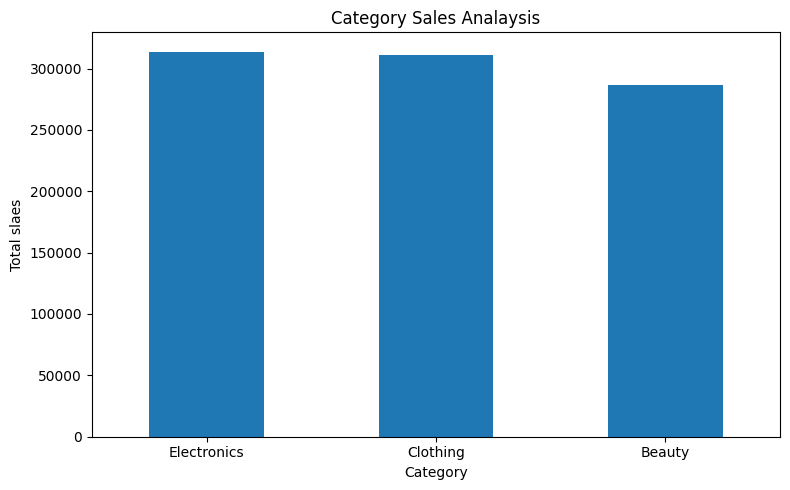

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby("category")["total_sale"].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Category Sales Analaysis")
plt.xlabel("Category")
plt.ylabel("Total slaes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


gender
Female    465400.0
Male      446320.0
Name: total_sale, dtype: float64


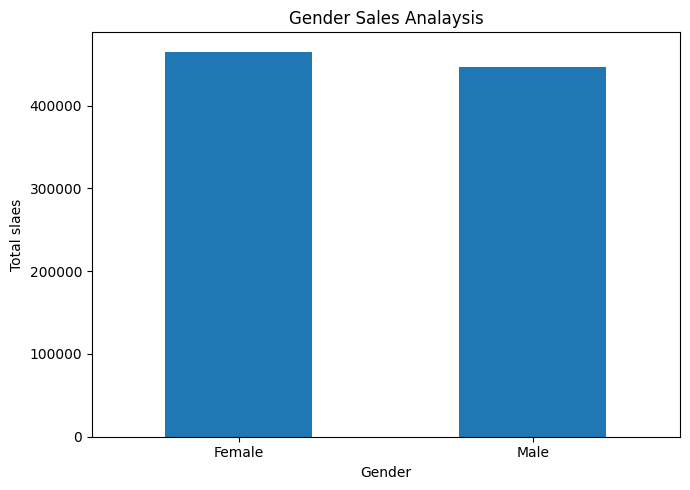

In [ ]:
import matplotlib.pyplot as plt

gender_sales = df.groupby("gender")["total_sale"].sum().sort_values(ascending=False)

print(gender_sales)

plt.figure(figsize=(7,5))
gender_sales.plot(kind="bar")
plt.title("Gender Sales Analaysis")
plt.xlabel("Gender")
plt.ylabel("Total slaes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


age_group
<20       69320.0
20-30    196430.0
30-40    191735.0
40-50    187590.0
50-60    196705.0
60+       66450.0
Name: total_sale, dtype: float64


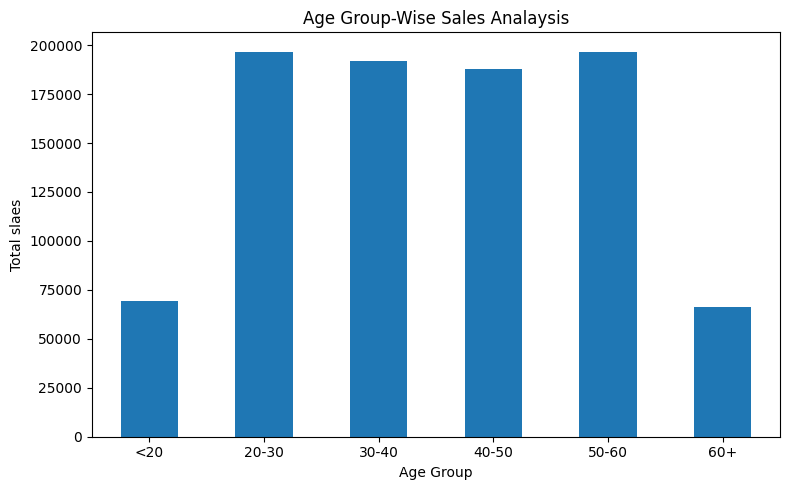

In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins = [0,20,30,40,50,60,100],
    labels = ["<20" , "20-30","30-40","40-50","50-60","60+"]
)
import matplotlib.pyplot as plt

age_sales = df.groupby("age_group", observed = False)["total_sale"].sum()

print(age_sales)

plt.figure(figsize=(8,5))
age_sales.plot(kind="bar")
plt.title("Age Group-Wise Sales Analaysis")
plt.xlabel("Age Group")
plt.ylabel("Total slaes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
top_category = df.groupby("category")["total_sale"].sum().sort_values(ascending=False)

print("Category Sales Ranking:")
print(top_category)

Category Sales Ranking:
category
Electronics    313810.0
Clothing       311070.0
Beauty         286840.0
Name: total_sale, dtype: float64


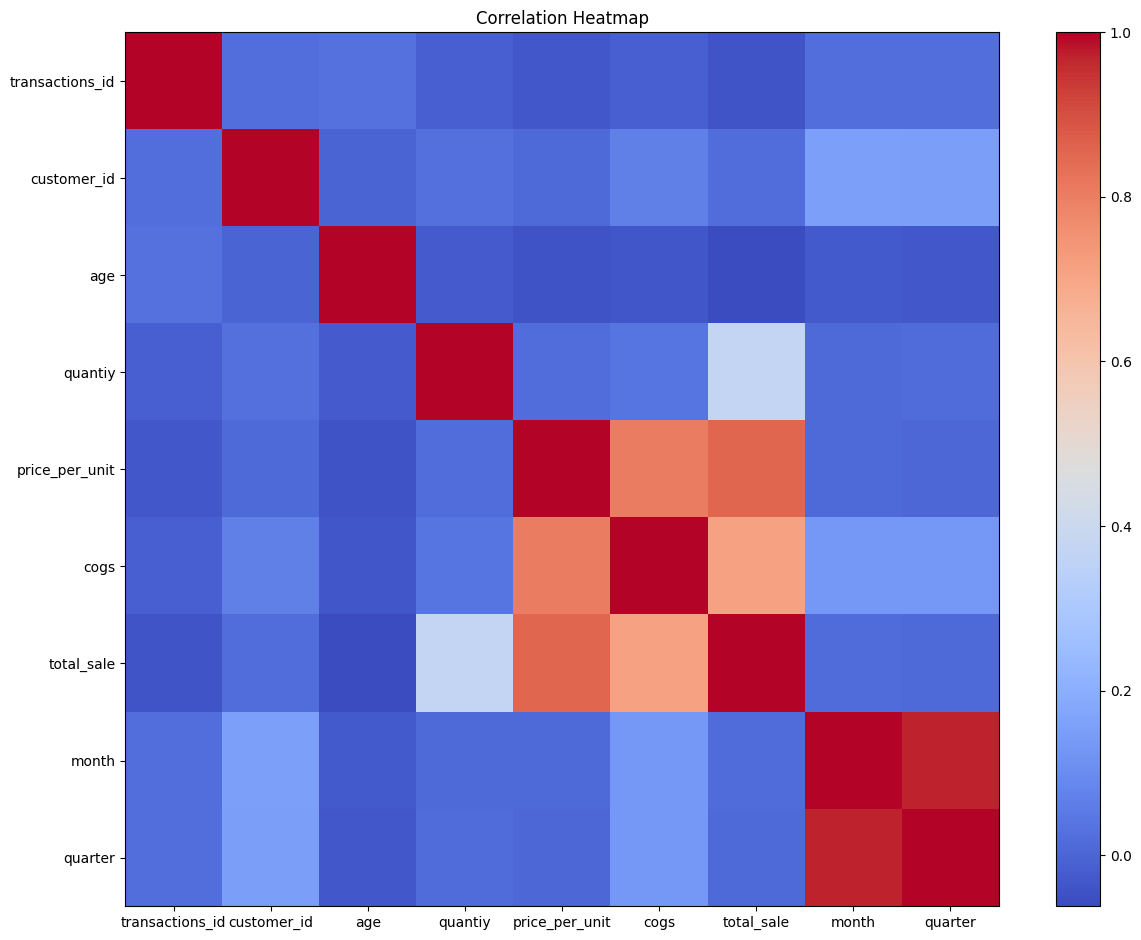

In [ ]:
import matplotlib.pyplot as plt

numeric_data= df.select_dtypes(include="number")
correlation = numeric_data.corr()

plt.figure(figsize=(12.5,9.5))
plt.imshow(correlation,cmap="coolwarm",interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),correlation.columns)

plt.yticks(
    range(len(correlation.columns)),correlation.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

        category  quantiy  total_sale
74   Electronics      4.0      2000.0
75        Beauty      4.0      2000.0
76   Electronics      4.0      2000.0
77        Beauty      4.0      2000.0
94   Electronics      4.0      2000.0
97   Electronics      4.0      2000.0
103     Clothing      4.0      2000.0
106     Clothing      4.0      2000.0
109       Beauty      4.0      2000.0
112       Beauty      4.0      2000.0


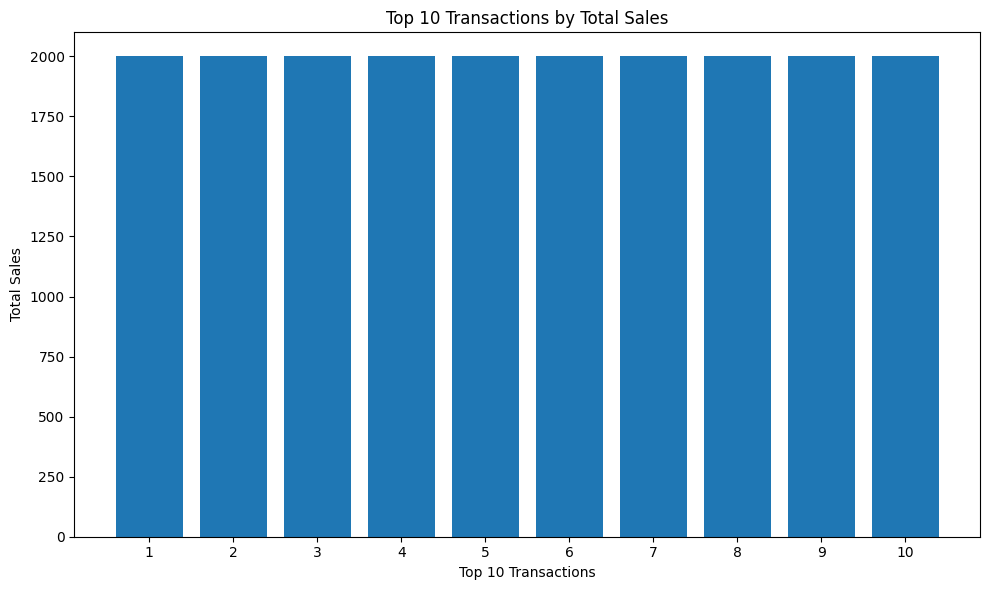

In [ ]:
top10 = df.nlargest(10, "total_sale")

print(top10[["category", "quantiy", "total_sale"]])

plt.figure(figsize=(10,6))
plt.bar(range(1,11), top10["total_sale"])
plt.title("Top 10 Transactions by Total Sales")
plt.xlabel("Top 10 Transactions")
plt.ylabel("Total Sales")
plt.xticks(range(1,11))
plt.tight_layout()
plt.show()

## Key Business Insights

* Sales show a clear upward trend toward the later months of the year, with the highest monthly sales recorded in December.

* Quarterly analysis shows that Q4 generated the highest total sales, while Q1 recorded the lowest sales.

* Sales performance is relatively similar across male and female customers, indicating that both customer groups contribute significantly to overall sales.

* The 20–30, 30–40, 40–50 and 50–60 age groups generated substantially higher sales than the below-20 age group.

* Electronics and Clothing generated higher sales compared with Beauty, indicating stronger revenue contribution from these categories.

* The correlation heatmap shows a strong positive relationship between quantity, price per unit, and total sales.

## Business Recommendations

* Focus marketing and promotional campaigns on the high-performing months, especially Q4, to maximize sales opportunities.

* Maintain sufficient inventory for high-demand categories such as Electronics and Clothing during peak sales periods.

* Use age-group analysis to create targeted offers and campaigns for the customer segments generating higher sales.

* Monitor lower-performing categories such as Beauty and identify opportunities through discounts, bundles, and targeted promotions.

* Analyze transaction-level sales regularly to identify high-value purchases and improve sales planning.

## Conclusion

The exploratory data analysis provided useful insights into the retail sales dataset. Sales increased significantly during the later months and Q4 recorded the highest quarterly sales. Electronics and Clothing were important contributors to revenue, while customers across the 20–60 age groups generated substantial sales. The analysis also highlighted relationships between key numerical variables through the correlation heatmap. These findings can support better inventory planning, targeted marketing, and data-driven sales strategies.